# Notebook 01 — Data Understanding and Problem Framing
**Project:** Mining Process Quality Prediction — Minsur Analytics Challenge  
**Level:** 1 (mandatory)  
**Target:** `% Silica Concentrate`  
**Author:** Analytics Candidate  

---

## Business Context

In the Minsur flotation process, the quality of the final iron ore concentrate
is measured by the **percentage of silica** (`% Silica Concentrate`) — a lower value
means purer iron concentrate. Laboratory quality measurements arrive with a
**significant delay** (up to several hours), which prevents real-time operational
decisions.

The goal of this project is to **predict % Silica Concentrate in real time**
using continuous sensor data (ore feed quality, reagent flows, flotation column
parameters), enabling operators to react proactively to quality excursions.

---

## Why Temporal Integrity Matters

> A random train/test split on time-series data introduces **data leakage**:
> the model would train on observations from March to predict January, effectively
> seeing the future. Evaluation metrics would be over-optimistic and the model
> would fail in production. We strictly respect the chronological ordering of
> all splits throughout this project.

In [1]:
# ---------------------------------------------------------------------------
# 0. Environment setup — add project root to sys.path so src/ is importable
# ---------------------------------------------------------------------------
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.config import CFG, PROJECT_ROOT
from src.data_preprocessing import (
    load_raw_data,
    normalize_column_names,
    parse_and_sort_datetime,
    remove_duplicates,
    data_quality_report,
    outlier_summary,
    sampling_frequency_report,
    run_preprocessing_pipeline,
)
from src.evaluate import compute_metrics

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
FIGURES_PATH = Path(CFG['paths']['reports_figures'])

TARGET = CFG['target']
print(f"Target: {TARGET}")

Target: % Silica Concentrate


---
## 1. Load Dataset

The raw CSV is expected in `data/raw/`. If not yet downloaded, run the Kaggle
download cell below (requires `kagglehub` and valid Kaggle credentials).

In [4]:
# ---------------------------------------------------------------------------

# Download via kagglehub if the file does not already exist

# (aligned with src.data_preprocessing auto-download behavior)

# ---------------------------------------------------------------------------

import shutil

import sys

import subprocess



try:

    import kagglehub

except ModuleNotFoundError:

    print('kagglehub not found in current kernel. Installing...')

    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'kagglehub'])

    import kagglehub



raw_dir = Path(CFG['paths']['data_raw'])

raw_file = raw_dir / CFG['data']['raw_filename']

raw_dir.mkdir(parents=True, exist_ok=True)



if not raw_file.exists():

    print('Downloading dataset from Kaggle via kagglehub.dataset_download...')

    dataset_dir = Path(

        kagglehub.dataset_download('edumagalhaes/quality-prediction-in-a-mining-process')

    )



    csv_candidates = sorted(dataset_dir.rglob('*.csv'))

    if not csv_candidates:

        raise FileNotFoundError(f'No CSV found in downloaded dataset path: {dataset_dir}')



    source_csv = next(

        (p for p in csv_candidates if 'mining' in p.name.lower() or 'flotation' in p.name.lower()),

        csv_candidates[0],

    )

    shutil.copy2(source_csv, raw_file)

    print(f'Copied: {source_csv} -> {raw_file}')

else:

    print(f'File already exists: {raw_file}')


kagglehub not found in current kernel. Installing...
File already exists: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\data\raw\MiningProcess_Flotation_Plant_Database.csv


In [13]:
# Load raw (uncleaned) to inspect as-is
df_raw = load_raw_data(CFG)
df_raw = normalize_column_names(df_raw)
print(f'Shape: {df_raw.shape}')
df_raw.head(3)

Shape: (737453, 24)


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,2017-03-10 01:00:00,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,...,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2,2017-03-10 01:00:00,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,...,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31


---
## 2. Datetime Parsing and Temporal Ordering

In [15]:
df = parse_and_sort_datetime(df_raw.copy(), CFG)
df = remove_duplicates(df)

print(f'Date range: {df.index.min()} → {df.index.max()}')
print(f'Shape after deduplication: {df.shape}')
df.head(3)

[data_preprocessing] Removed 733356 duplicate rows.
Date range: 2017-03-10 01:00:00 → 2017-09-09 23:00:00
Shape after deduplication: (4097, 23)


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
date,,,,,,,,,,,,,,,,,,,,,
2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74000,249.214,253.235,250.576,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
2017-03-10 02:00:00,55.2,16.98,3428.03,550.659,403.169,10.0866,1.68463,251.082,251.213,250.785,...,249.708,446.110,500.306,453.359,453.164,444.589,444.858,466.510,67.06,1.11
2017-03-10 03:00:00,55.2,16.98,3388.18,597.076,391.040,10.0170,1.75000,250.873,247.083,249.829,...,248.950,456.320,463.180,440.948,485.158,453.427,458.550,465.823,66.97,1.27


---
## 3. Target and Feature Identification

In [8]:
# Identify target and candidate predictors
lab_cols = CFG['feature_groups']['lab_measurements']  # delayed — NOT predictors

feature_candidates = [c for c in df.columns if c not in lab_cols]

print(f'Target: {TARGET}')
print(f'\nLab measurement columns (delayed — excluded from features):')
print(lab_cols)
print(f'\nCandidate predictors ({len(feature_candidates)}):')
for c in feature_candidates:
    print(f'  {c}')

Target: % Silica Concentrate

Lab measurement columns (delayed — excluded from features):
['% Iron Concentrate', '% Silica Concentrate']

Candidate predictors (21):
  % Iron Feed
  % Silica Feed
  Starch Flow
  Amina Flow
  Ore Pulp Flow
  Ore Pulp pH
  Ore Pulp Density
  Flotation Column 01 Air Flow
  Flotation Column 02 Air Flow
  Flotation Column 03 Air Flow
  Flotation Column 04 Air Flow
  Flotation Column 05 Air Flow
  Flotation Column 06 Air Flow
  Flotation Column 07 Air Flow
  Flotation Column 01 Level
  Flotation Column 02 Level
  Flotation Column 03 Level
  Flotation Column 04 Level
  Flotation Column 05 Level
  Flotation Column 06 Level
  Flotation Column 07 Level


> **Design decision — Leakage guard:**  
> `% Iron Concentrate` and `% Silica Concentrate` are laboratory measurements
> that are updated only once per hour (or less frequently) and always arrive
> **after** the sensor readings they correspond to. Using them directly as
> features would be leakage — at inference time they are not yet available.
> Only **lagged** versions (shift ≥ 1) are acceptable, and only when documented.

---
## 4. Data Quality Analysis

In [9]:
report = data_quality_report(df)
print('=== Data Quality Report ===')
report

=== Data Quality Report ===


,dtype,n_missing,pct_missing,n_unique,min,max,mean,std,n_dup_rows_total
% Iron Feed,float64,0,0.0,278,42.740000,65.780000,56.2947,5.1583,0
% Silica Feed,float64,0,0.0,293,1.310000,33.400000,14.6517,6.8082,0
Starch Flow,float64,0,0.0,4054,0.610020,6278.511875,2869.4390,1215.1910,0
Amina Flow,float64,0,0.0,3962,241.773000,736.925639,488.2623,91.1031,0
Ore Pulp Flow,float64,0,0.0,3688,376.296000,418.480804,397.6520,9.6974,0
Ore Pulp pH,float64,0,0.0,3875,8.753394,10.807653,9.7680,0.3866,0
Ore Pulp Density,float64,0,0.0,3677,1.519869,1.849843,1.6802,0.0694,0
Flotation Column 01 Air Flow,float64,0,0.0,2645,175.796212,353.203533,280.1822,29.6059,0
Flotation Column 02 Air Flow,float64,0,0.0,3682,177.784806,366.781000,277.1839,30.0850,0
Flotation Column 03 Air Flow,float64,0,0.0,3024,176.772384,345.139599,281.0969,28.5617,0


In [10]:
# Missing values summary
missing = report[['n_missing', 'pct_missing']].sort_values('n_missing', ascending=False)
print('Missing values per column:')
print(missing[missing['n_missing'] > 0])
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing values per column:
Empty DataFrame
Columns: [n_missing, pct_missing]
Index: []

Total missing: 0


In [11]:
# Outlier summary (IQR × 3)
out_summary = outlier_summary(df)
print('Outlier summary (IQR × 3 factor):')
print(out_summary.head(15))

Outlier summary (IQR × 3 factor):
                              n_outliers  pct_outliers
% Iron Feed                            0           0.0
% Silica Feed                          0           0.0
Starch Flow                            0           0.0
Amina Flow                             0           0.0
Ore Pulp Flow                          0           0.0
Ore Pulp pH                            0           0.0
Ore Pulp Density                       0           0.0
Flotation Column 01 Air Flow           0           0.0
Flotation Column 02 Air Flow           0           0.0
Flotation Column 03 Air Flow           0           0.0
Flotation Column 04 Air Flow           0           0.0
Flotation Column 05 Air Flow           0           0.0
Flotation Column 06 Air Flow           0           0.0
Flotation Column 07 Air Flow           0           0.0
Flotation Column 01 Level              0           0.0


In [12]:
# Sampling frequency analysis
freq_report = sampling_frequency_report(df)
print('Inter-sample time deltas (minutes):')
print(freq_report.head(10))

Inter-sample time deltas (minutes):
   delta_minutes  count
0           60.0   4095
1        19140.0      1


### Mixed Sampling Frequencies — Implications

The dataset contains variables with **different update frequencies**:

| Variable group | Approx. update frequency |
|---|---|
| Sensor data (flows, levels, pH, density) | Every ~20 minutes |
| Lab measurements (`% Iron`, `% Silica Concentrate`) | Every ~1 hour (with delay) |

**Implications:**
1. **Repeated values**: Lab columns hold the same value for multiple consecutive rows, creating
   artificially high autocorrelation and potentially misleading correlation statistics.
2. **Leakage risk**: Because lab readings are recorded at irregular intervals, any model that
   uses the current lab value as a feature would be using a value that was not yet available
   at the time the sensor reading was taken.
3. **Rolling feature design**: When computing rolling statistics, we must ensure the window
   size is chosen in physical time, not just in row count, since rows are not equally spaced.
4. **Target smoothing**: The target variable itself (`% Silica Concentrate`) may appear
   'frozen' for several consecutive rows. This introduces autocorrelation that models must
   not exploit in a leaky way.

---
## 5. Visual Analysis

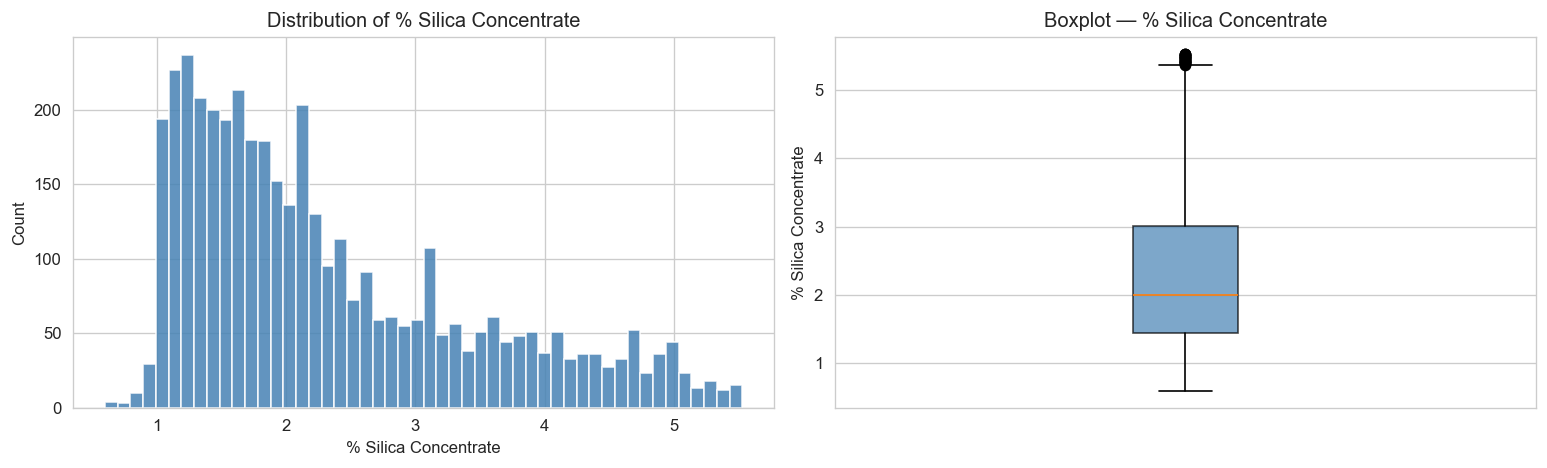

count    4097.0000
mean        2.3261
std         1.1240
min         0.6000
25%         1.4400
50%         2.0000
75%         3.0100
max         5.5300
Name: % Silica Concentrate, dtype: float64


In [16]:
# ── 5a. Target distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df[TARGET].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title(f'Distribution of {TARGET}', fontsize=12)
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel('Count')

axes[1].boxplot(df[TARGET].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title(f'Boxplot — {TARGET}', fontsize=12)
axes[1].set_ylabel(TARGET)
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(df[TARGET].describe().round(4))

### Hallazgo corto — Target distribution

La variable `% Silica Concentrate` está **sesgada a la derecha**: la mayor densidad cae entre ~1.0 y 2.5, con mediana cercana a **2.0** y una cola hacia valores altos (hasta ~5.53). Esto sugiere episodios menos frecuentes de sílice elevada (peor calidad), por lo que en modelado conviene vigilar errores grandes (RMSE y análisis de residuos) además del MAE.

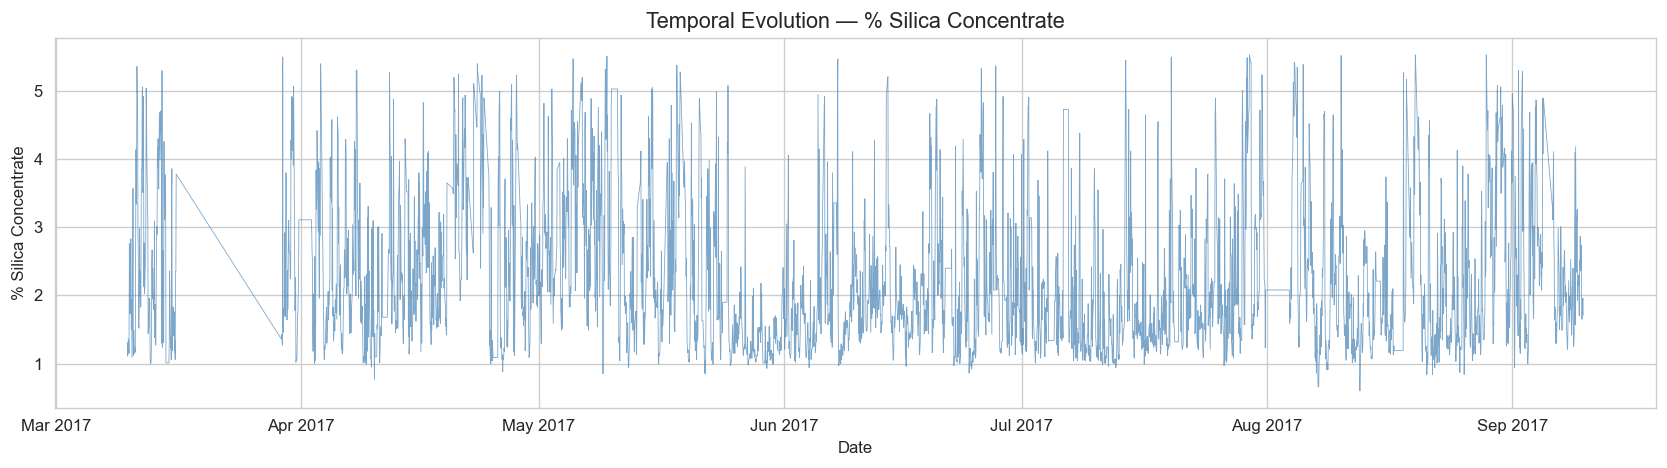

In [17]:
# ── 5b. Temporal evolution of the target ─────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df[TARGET], lw=0.5, color='steelblue', alpha=0.7)
ax.set_title(f'Temporal Evolution — {TARGET}', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel(TARGET)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'target_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

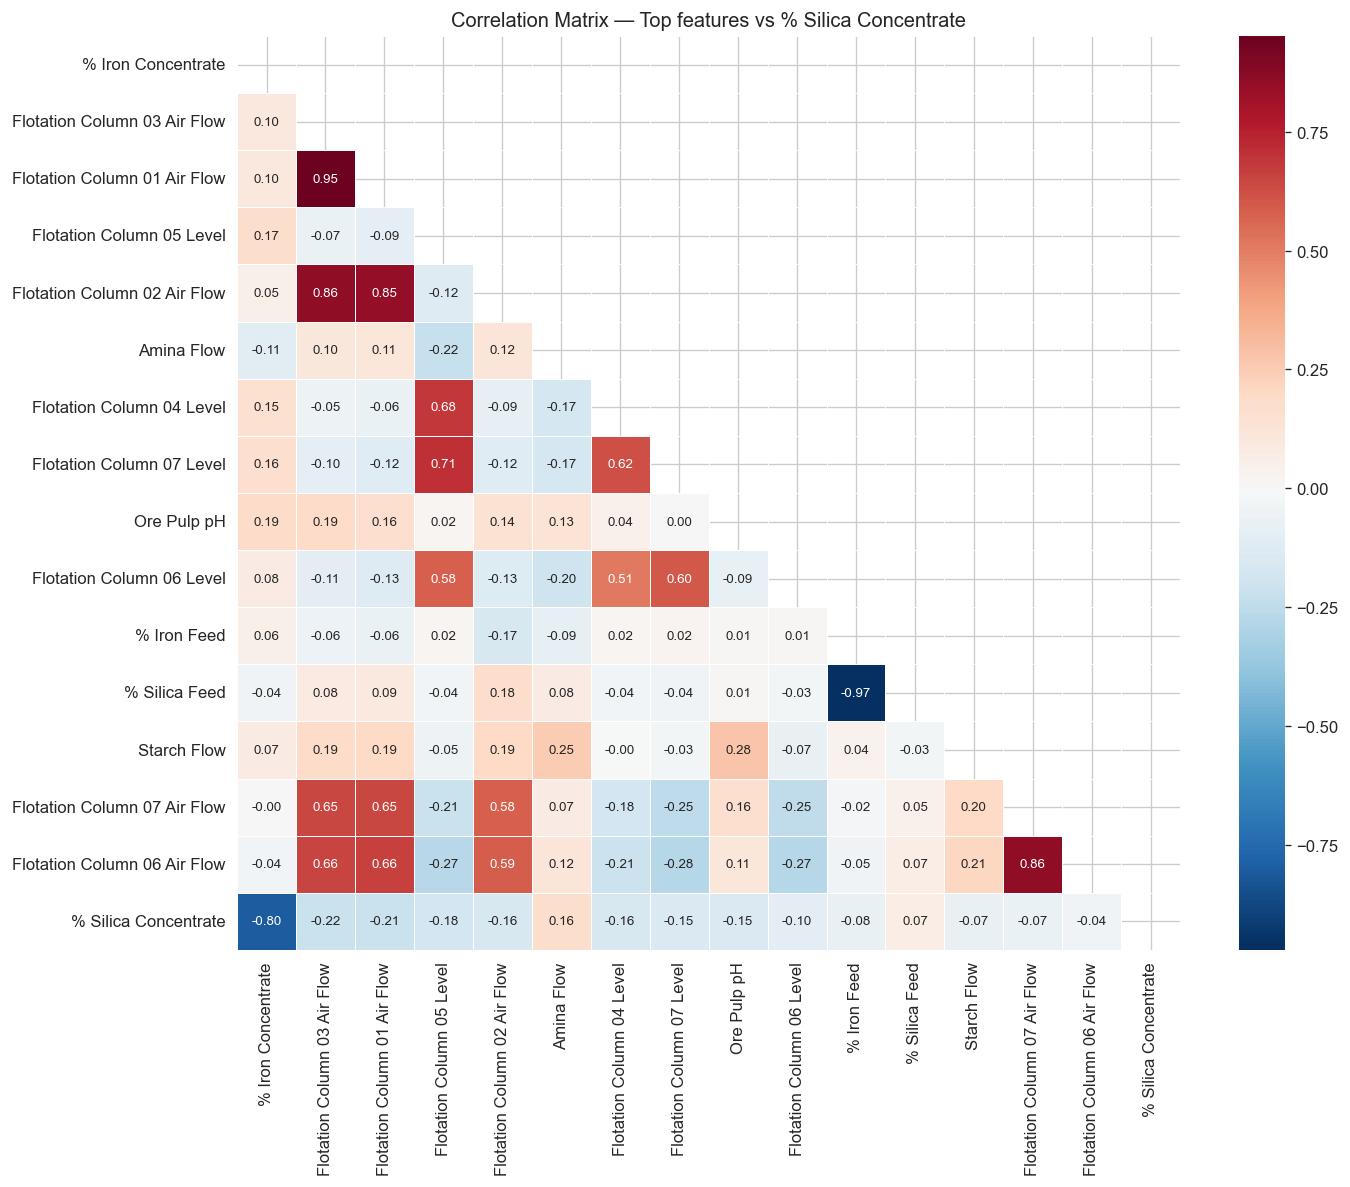


Top 10 correlations with target:
% Iron Concentrate             -0.800
Flotation Column 03 Air Flow   -0.219
Flotation Column 01 Air Flow   -0.214
Flotation Column 05 Level      -0.179
Flotation Column 02 Air Flow   -0.163
Amina Flow                      0.163
Flotation Column 04 Level      -0.162
Flotation Column 07 Level      -0.148
Ore Pulp pH                    -0.146
Flotation Column 06 Level      -0.104
Name: % Silica Concentrate, dtype: float64


In [18]:
# ── 5c. Correlation matrix ────────────────────────────────────────────────
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

# Focus on top correlated features with target
target_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
top_cols = target_corr.head(15).index.tolist() + [TARGET]

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr.loc[top_cols, top_cols], dtype=bool))
sns.heatmap(
    corr.loc[top_cols, top_cols],
    annot=True, fmt='.2f', mask=mask, cmap='RdBu_r',
    center=0, linewidths=0.5, ax=ax, annot_kws={'fontsize': 8}
)
ax.set_title(f'Correlation Matrix — Top features vs {TARGET}', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 correlations with target:')
print(target_corr.head(10).round(3))

### Conclusiones de la mtriz de correlación

> Estas correlaciones son **lineales** y **no implican causalidad**. Se usan para entender señales preliminares y riesgos de modelado.

1. **Driver más fuerte del target:** `% Iron Concentrate` muestra una correlación alta y negativa con `% Silica Concentrate` (≈ -0.80).
   - Es coherente metalúrgicamente (más hierro en concentrado suele implicar menos sílice).
   - **Pero esta variable es de laboratorio y llega con retraso**, por lo que no debe usarse como feature directa en inferencia online (riesgo de leakage).

2. **Señales operativas con impacto moderado en sílice:**
   - `Flotation Column 03 Air Flow` y `Flotation Column 01 Air Flow` aparecen con correlación negativa moderada (≈ -0.22 / -0.21).
   - `Amina Flow` aparece con correlación positiva moderada (≈ +0.16), sugiriendo comportamiento no lineal o interacción con otras variables.
   - `Ore Pulp pH` y niveles de columnas muestran efectos débiles a moderados, útiles para feature engineering.

3. **Multicolinealidad fuerte entre variables de proceso:**
   - Flujos de aire entre columnas están altamente correlacionados entre sí (ej. ≈ 0.85–0.95).
   - `% Iron Feed` y `% Silica Feed` tienen correlación muy alta en magnitud (≈ -0.97).
   - Implicancia: para modelos lineales conviene regularización (Ridge) y para árboles revisar importancia/SHAP para evitar interpretaciones engañosas.

4. **Implicancia para la siguiente etapa (Level 2):**
   - Priorizar variables operativas disponibles en tiempo real.
   - Excluir variables de laboratorio contemporáneas.
   - Incorporar lags, rolling means/std e interacciones para capturar dinámica temporal y no depender solo de correlación instantánea.

---
## 6. Metric Definitions and Baseline Model

### Metrics

| Metric | Formula | Interpretation |
|---|---|---|
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Average absolute error in % Silica units |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Penalises large errors; relevant for quality excursions |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Proportion of variance explained; 1.0 = perfect |

### Baseline Strategy
The simplest possible model: **predict the mean of the training target for every observation**.  
Any useful model must beat this baseline; otherwise it provides no value over the current
status quo of 'just use the average'.

In [20]:
# ---------------------------------------------------------------------------
# Temporal split for baseline evaluation — NO random split allowed
# ---------------------------------------------------------------------------
from src.feature_engineering import temporal_split

# Use the cleaned full DataFrame (no feature engineering yet)
df_clean = df.dropna(subset=[TARGET])

train_df, val_df, test_df = temporal_split(
    df_clean,
    train_ratio=CFG['split']['train_ratio'],
    val_ratio=CFG['split']['val_ratio'],
)

[feature_engineering] Split sizes — train: 2867 (70%), val: 615 (15%), test: 615 (15%)
  Train: 2017-03-10 01:00:00 → 2017-07-20 17:00:00
  Val:   2017-07-20 18:00:00 → 2017-08-15 08:00:00
  Test:  2017-08-15 09:00:00 → 2017-09-09 23:00:00


In [21]:
# Baseline: predict training mean on all splits
train_mean = train_df[TARGET].mean()

baseline_results = {}
for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    y_true = split_df[TARGET]
    y_pred = np.full(len(y_true), train_mean)
    metrics = compute_metrics(y_true, y_pred)
    baseline_results[split_name] = metrics
    print(f'Baseline ({split_name}): {metrics}')

print(f'\nBaseline prediction (mean of training target): {train_mean:.4f}')

Baseline (Train): {'MAE': 0.923, 'RMSE': np.float64(1.1254), 'R2': 0.0}
Baseline (Val): {'MAE': 0.79, 'RMSE': np.float64(1.033), 'R2': -0.0023}
Baseline (Test): {'MAE': 0.9916, 'RMSE': np.float64(1.2011), 'R2': -0.0083}

Baseline prediction (mean of training target): 2.3173


In [22]:
# Save baseline metrics for comparison in notebook 02
import json
metrics_path = Path(CFG['paths']['reports_metrics'])
with open(metrics_path / 'baseline_metrics.json', 'w') as f:
    json.dump(baseline_results, f, indent=2)
print(f'Baseline metrics saved to: {metrics_path / "baseline_metrics.json"}')

Baseline metrics saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\baseline_metrics.json


---
## 7. Save Cleaned Data for Downstream Notebooks

In [3]:
# Run the full preprocessing pipeline and persist to data/interim/

import sys

import subprocess



# Ensure parquet engine exists in the active notebook kernel

try:

    import pyarrow  # noqa: F401

except ModuleNotFoundError:

    print('pyarrow not found in current kernel. Installing...')

    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pyarrow'])



df_cleaned = run_preprocessing_pipeline(CFG)

print(f'Cleaned data shape: {df_cleaned.shape}')

df_cleaned.head(3)


[data_preprocessing] Removed 733356 duplicate rows.
[data_preprocessing] Cleaned data saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\data\interim\data_cleaned.parquet (engine=pyarrow)
[data_preprocessing] Shape: (4097, 23)
Cleaned data shape: (4097, 23)


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
date,,,,,,,,,,,,,,,,,,,,,
2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74000,249.214,253.235,250.576,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
2017-03-10 02:00:00,55.2,16.98,3428.03,550.659,403.169,10.0866,1.68463,251.082,251.213,250.785,...,249.708,446.110,500.306,453.359,453.164,444.589,444.858,466.510,67.06,1.11
2017-03-10 03:00:00,55.2,16.98,3388.18,597.076,391.040,10.0170,1.75000,250.873,247.083,249.829,...,248.950,456.320,463.180,440.948,485.158,453.427,458.550,465.823,66.97,1.27


---
## Summary — Level 1 Checklist

| Item | Status |
|---|---|
| Dataset loaded from `data/raw/` | ✅ |
| Datetime column parsed and sorted | ✅ |
| Target identified: `% Silica Concentrate` | ✅ |
| Candidate predictors identified | ✅ |
| Missing values analysed | ✅ |
| Duplicates removed | ✅ |
| Outliers flagged (IQR × 3) | ✅ |
| Mixed sampling frequencies explained | ✅ |
| Visual analysis (distribution, temporal, correlation, missing) | ✅ |
| Metric definitions (MAE, RMSE, R²) | ✅ |
| Baseline model implemented and evaluated | ✅ |
| No random split — temporal integrity preserved | ✅ |
| No data leakage | ✅ |